# Water Quality Prediction (WQI) – Model Comparison

## 1. Libraries

In [36]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print('Libraries loaded.')
print('PyTorch version:', torch.__version__)

Libraries loaded.
PyTorch version: 2.8.0


## 2. Učitavanje podataka

In [ ]:
try:
    df_water = pd.read_csv('data/brisbane_water_quality.csv')
    df_water['Timestamp'] = pd.to_datetime(df_water['Timestamp'])

except FileNotFoundError:
    print("ERROR: water_quality.csv not found.")
    raise

try:
    df_rain = pd.read_csv('data/RainfallData.csv')
    df_rain.columns = df_rain.columns.str.strip()
    df_rain['Date'] = pd.to_datetime(df_rain[['Year', 'Month', 'Day']])
    df_rain_clean = df_rain[
        df_rain['Rainfall amount (millimetres)'].notna()
    ][[
        'Date',
        'Rainfall amount (millimetres)'
    ]]
    df_rain_clean = df_rain_clean.rename(
        columns={
            'Rainfall amount (millimetres)': 'Rainfall'
        }
    )
    df_rain_clean = (
        df_rain_clean
        .groupby('Date', as_index=False)['Rainfall']
        .sum()
    )

except FileNotFoundError:
    print("ERROR: Rainfall file not found.")
    raise
    
df_water['Date_join'] = df_water['Timestamp'].dt.normalize()

df_merged = pd.merge(
    df_water,
    df_rain_clean,
    left_on='Date_join',
    right_on='Date',
    how='left'
)

df_merged = df_merged.set_index('Timestamp')
cols_drop = [c for c in df_merged.columns if '[quality]' in c]
cols_drop += [
    'Salinity',
    'Dissolved Oxygen (%Saturation)',
    'Record number',
    'Date_join',
    'Date'
]

df_raw = df_merged.drop(
    columns=[c for c in cols_drop if c in df_merged.columns]
)

print(f"Loaded {len(df_raw)} rows, {len(df_raw.columns)} columns.")

print("\nMissing values per column:")
print(df_raw.isnull().sum().to_string())

Loaded 30894 rows, 9 colons.

Missing values per column:
Average Water Speed          20
Average Water Direction       1
Chlorophyll                 585
Temperature                5164
Dissolved Oxygen           4300
pH                         1084
Specific Conductance       1367
Turbidity                  2000
Rainfall                      0


## 3. Missing values - interpolation

In [34]:
df = df_raw.copy()
df = df.interpolate(method='time')
df = df.ffill().bfill()

print("Interpolation done.")
print(df.isnull().sum().to_string())

Interpolation done.
Average Water Speed        0
Average Water Direction    0
Chlorophyll                0
Temperature                0
Dissolved Oxygen           0
pH                         0
Specific Conductance       0
Turbidity                  0
Rainfall                   0


## 4. WQI function

In [38]:
def calculate_wqi(row):
    params = {
        'pH':   {'val': row.get('pH'),                  'S': 8.5,    'V_ideal': 7.0,  'W': 0.12},
        'DO':   {'val': row.get('Dissolved Oxygen'),     'S': 5.0,    'V_ideal': 14.6, 'W': 0.37},
        'Turb': {'val': row.get('Turbidity'),            'S': 5.0,    'V_ideal': 0.0,  'W': 0.18},
        'Cond': {'val': row.get('Specific Conductance'), 'S': 1000.0, 'V_ideal': 0.0,  'W': 0.18},
        'Chl':  {'val': row.get('Chlorophyll'),          'S': 10.0,   'V_ideal': 0.0,  'W': 0.15},
    }

    ws, wt = 0.0, 0.0

    for p, d in params.items():
        if d['val'] is None or pd.isna(d['val']):
            continue

        qi = (
            100.0 * ((d['V_ideal'] - d['val']) / (d['V_ideal'] - d['S']))
            if p == 'DO'
            else 100.0 * (abs(d['val'] - d['V_ideal']) / abs(d['S'] - d['V_ideal']))
        )

        ws += float(np.clip(qi, 0, 100)) * d['W']
        wt += d['W']

    return ws / wt if wt > 0 else np.nan


print("WQI function defined.")


df['WQI'] = df.apply(calculate_wqi, axis=1)
df['WQI'] = df['WQI'].ffill().bfill()

print(f"WQI calculated:  {df['WQI'].min():.2f} - {df['WQI'].max():.2f}")

WQI function defined.
WQI calculated:  39.60 - 76.47


## 5. Attribute Distributions Before Outlier Treatment

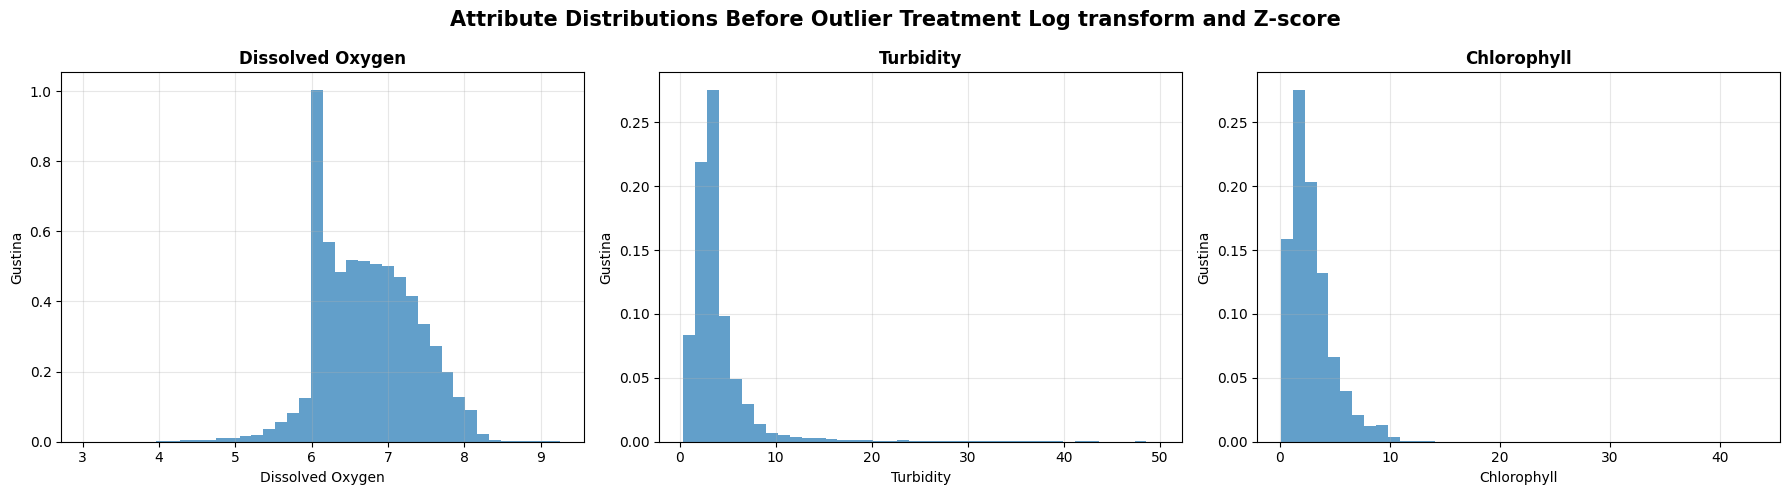

In [40]:
columns = ['Dissolved Oxygen', 'Turbidity', 'Chlorophyll']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, columns):
    ax.hist(df[col].dropna(), bins=40, density=True, alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Gustina')
    ax.grid(alpha=0.3)

plt.suptitle('Attribute Distributions Before Outlier Treatment Log transform and Z-score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Log transform and Z-score

In [41]:
for col in ['Turbidity', 'Chlorophyll']:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))

print("Log transform done for Turbidity and Chlorophyll.")

OCOLS = ['Dissolved Oxygen', 'Turbidity', 'Chlorophyll']

for col in OCOLS:
    if col in df.columns:
        mean_val = df[col].mean()
        std_val = df[col].std()

        if std_val > 0:
            lower_limit = mean_val - 3 * std_val
            upper_limit = mean_val + 3 * std_val

            df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Z-score clipping done.")

Log transform done for Turbidity and Chlorophyll.
Z-score clipping done.


## 7. Attribute Distributions After Outlier Treatment

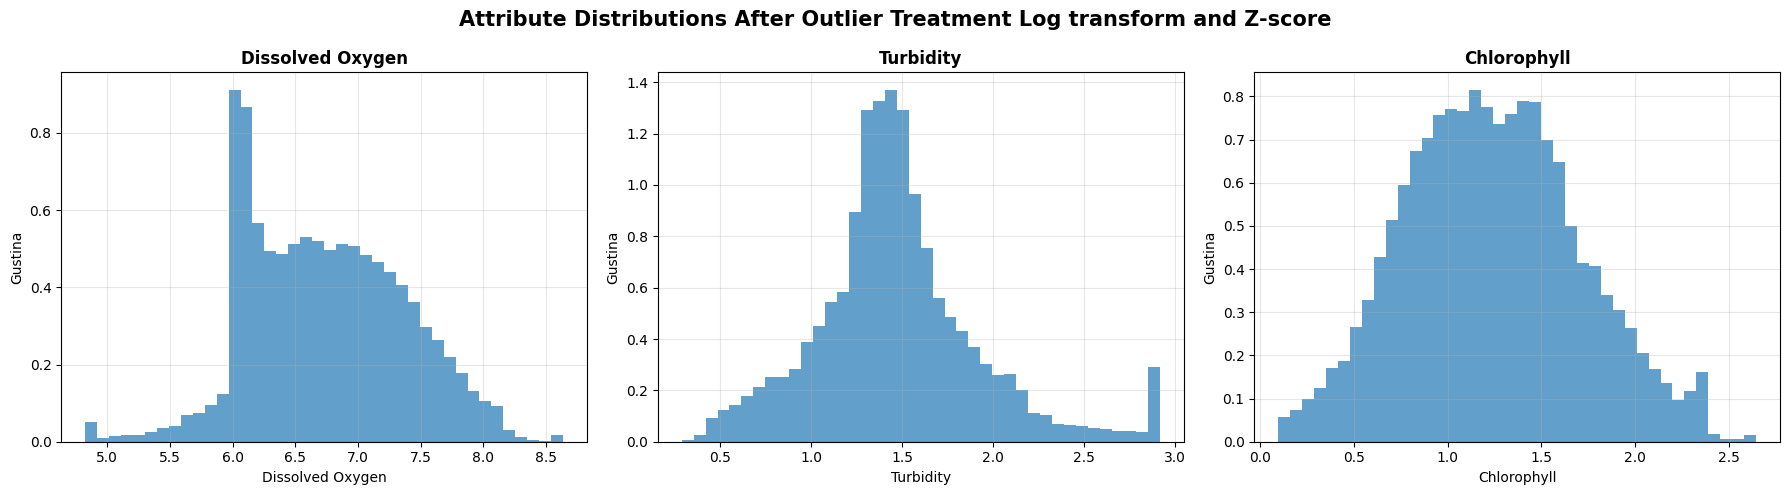

In [ ]:
columns = ['Dissolved Oxygen', 'Turbidity', 'Chlorophyll']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, columns):
    ax.hist(df[col].dropna(), bins=40, density=True, alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(alpha=0.3)

plt.suptitle('Attribute Distributions After Outlier Treatment Log transform and Z-score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Dropping duplicates

In [43]:
df.drop_duplicates(inplace=True)
print(f"Rows after dropping duplicates: {len(df)}")

Rows after dropping duplicates: 30619


## 9. Feature Preparation

In [44]:
def prepare_features(df):
    df = df.copy()

    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day_of_Year'] = df.index.dayofyear
    df['Hour'] = df.index.hour
    df['Day_of_Week'] = df.index.dayofweek

    df = df.dropna(subset=['WQI'])

    X = df.drop(columns=['WQI'])
    y = df['WQI']

    return X, y


X, y = prepare_features(df)

print(f'Shape X: {X.shape} | WQI range: {y.min():.2f}–{y.max():.2f}')

Shape X: (30619, 14) | WQI range: 39.60–76.47


## 10. Target Variable Visualization


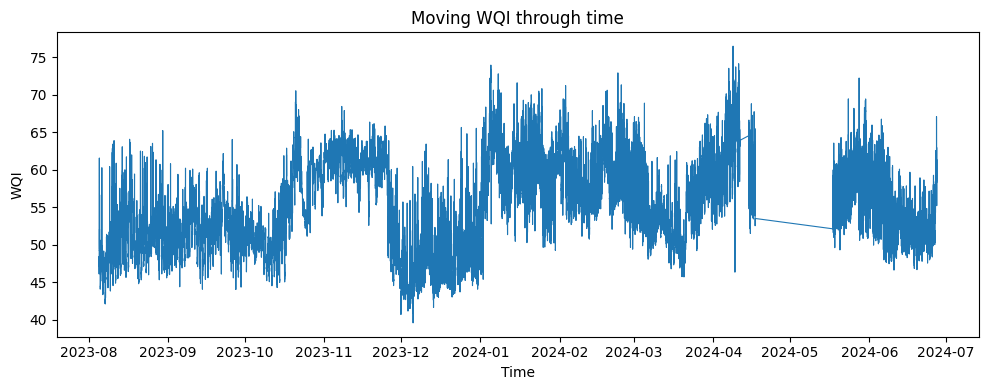

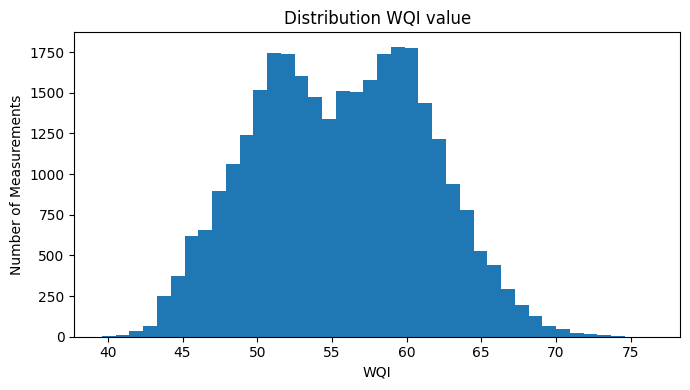

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(y.index, y.values, linewidth=0.8)
plt.title('Moving WQI through time')
plt.xlabel('Time')
plt.ylabel('WQI')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(y.dropna(), bins=40)
plt.title('Distribution WQI value')
plt.xlabel('WQI')
plt.ylabel('Number of Measurements')
plt.tight_layout()
plt.show()

## 11. Dataset Splitting and Scaling

In [47]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train data: {X_train_sc.shape}")
print(f"Test data: {X_test_sc.shape}")

Train data: (24495, 14)
Test data: (6124, 14)


## 12. Evaluate predictions function

In [48]:
def evaluate_predictions(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

results = []
all_predictions = {}
best_params = {}

## 12. Grid Search

In [51]:
tscv = TimeSeriesSplit(n_splits=3)

models_grid = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },

    'Ridge Regression': {
        'model': Ridge(),
        'params': {
            'alpha': [0.1, 1, 10]
        }
    },

    'Random Forest': {
        'model': RandomForestRegressor(random_state=SEED, n_jobs=1),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [8, 12],
            'min_samples_leaf': [1, 2]
        }
    },

    'XGBoost': {
        'model': XGBRegressor(
            objective='reg:squarederror',
            random_state=SEED,
            n_jobs=1
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1]
        }
    },

    'MLP Neural Network': {
        'model': MLPRegressor(
            solver='adam',
            early_stopping=True,
            random_state=SEED
        ),
        'params': {
            'hidden_layer_sizes': [(64, 32), (128, 64)],
            'alpha': [0.0001, 0.001],
            'learning_rate_init': [0.001],
            'max_iter': [300]
        }
    }
}

best_models = {}

for name, item in models_grid.items():
    print('\n===================================')
    print(f'GRID SEARCH: {name}')
    print('===================================')

    grid = GridSearchCV(
        estimator=item['model'],
        param_grid=item['params'],
        scoring='r2',
        cv=tscv,
        n_jobs=1
    )

    grid.fit(X_train_sc, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model
    best_params[name] = grid.best_params_

    y_pred = best_model.predict(X_test_sc)
    all_predictions[name] = y_pred

    metrics = evaluate_predictions(y_test, y_pred, name)
    results.append(metrics)

    print("Best params:")
    print(grid.best_params_)
    print(f"Best CV R2: {grid.best_score_:.4f}")

    print("\nTest results:")
    print(f"MAE  : {metrics['MAE']:.4f}")
    print(f"MSE  : {metrics['MSE']:.4f}")
    print(f"RMSE : {metrics['RMSE']:.4f}")
    print(f"R2   : {metrics['R2 Score']:.4f}")


GRID SEARCH: Linear Regression
Best params:
{}
Best CV R2: 0.6375

Test results:
MAE  : 2.3313
MSE  : 7.8579
RMSE : 2.8032
R2   : 0.6007

GRID SEARCH: Ridge Regression
Best params:
{'alpha': 10}
Best CV R2: 0.7339

Test results:
MAE  : 2.0453
MSE  : 6.8367
RMSE : 2.6147
R2   : 0.6526

GRID SEARCH: Random Forest
Best params:
{'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV R2: 0.9348

Test results:
MAE  : 0.4442
MSE  : 0.3036
RMSE : 0.5510
R2   : 0.9846

GRID SEARCH: XGBoost
Best params:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV R2: 0.9710

Test results:
MAE  : 0.3275
MSE  : 0.1671
RMSE : 0.4088
R2   : 0.9915

GRID SEARCH: MLP Neural Network
Best params:
{'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 300}
Best CV R2: 0.7563

Test results:
MAE  : 0.3040
MSE  : 0.1512
RMSE : 0.3888
R2   : 0.9923


## 13. Manual Grid Search for Transformer

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def create_sequences(X_array, y_array, seq_len=12):
    X_seq, y_seq = [], []
    y_values = np.asarray(y_array)

    for i in range(seq_len - 1, len(X_array)):
        X_seq.append(X_array[i-seq_len+1:i+1])
        y_seq.append(y_values[i])

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


SEQ_LEN = 12

Xtr_seq, ytr_seq = create_sequences(X_train_sc, y_train, SEQ_LEN)
Xte_seq, yte_seq = create_sequences(X_test_sc, y_test, SEQ_LEN)

y_mean = ytr_seq.mean()
y_std = ytr_seq.std()

ytr_seq_scaled = (ytr_seq - y_mean) / y_std

MAX_TRANSFORMER_TRAIN = 5000

if len(Xtr_seq) > MAX_TRANSFORMER_TRAIN:
    Xtr_seq_model = Xtr_seq[-MAX_TRANSFORMER_TRAIN:]
    ytr_seq_scaled_model = ytr_seq_scaled[-MAX_TRANSFORMER_TRAIN:]
else:
    Xtr_seq_model = Xtr_seq
    ytr_seq_scaled_model = ytr_seq_scaled

print("Transformer training sequence everything:", Xtr_seq.shape)
print("Transformer training sequence preparation:", Xtr_seq_model.shape)
print("Transformer test sequence:", Xte_seq.shape)


class TransformerRegressor(nn.Module):
    def __init__(
        self,
        input_dim,
        d_model=16,
        nhead=4,
        num_layers=1,
        dim_feedforward=32,
        dropout=0.1
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)

        self.pos_embedding = nn.Parameter(
            torch.zeros(1, SEQ_LEN, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='relu'
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.input_projection(x) + self.pos_embedding[:, :x.size(1), :]
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.regressor(x).squeeze(-1)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)


def train_transformer_model(
    d_model=16,
    num_layers=1,
    learning_rate=0.001,
    epochs=60,
    batch_size=512
):
    torch.manual_seed(SEED)

    train_ds = TensorDataset(
        torch.tensor(Xtr_seq_model, dtype=torch.float32),
        torch.tensor(ytr_seq_scaled_model, dtype=torch.float32)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False
    )

    model = TransformerRegressor(
        input_dim=Xtr_seq.shape[2],
        d_model=d_model,
        nhead=4,
        num_layers=num_layers,
        dim_feedforward=d_model * 2,
        dropout=0.1
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        loss_history.append(float(np.mean(epoch_losses)))

    model.eval()

    with torch.no_grad():
        Xte_tensor = torch.tensor(Xte_seq, dtype=torch.float32).to(DEVICE)
        pred_scaled = model(Xte_tensor).cpu().numpy()

    pred_original = pred_scaled * y_std + y_mean

    metrics = evaluate_predictions(
        yte_seq,
        pred_original,
        'Transformer Regressor'
    )

    return model, pred_original, metrics, loss_history

Transformer training sequence everything: (24484, 12, 14)
Transformer training sequence preparation: (5000, 12, 14)
Transformer test sequence: (6113, 12, 14)
Device: cpu


## 14. Running Manual Grid Search

In [53]:
transformer_grid = [
    {'d_model': 16, 'num_layers': 1, 'learning_rate': 0.001},
    {'d_model': 32, 'num_layers': 1, 'learning_rate': 0.001},
    {'d_model': 32, 'num_layers': 2, 'learning_rate': 0.001},
    {'d_model': 32, 'num_layers': 1, 'learning_rate': 0.0005},
]

transformer_results = []
best_transformer = None
best_transformer_pred = None
best_transformer_loss = None
best_transformer_r2 = -np.inf
best_transformer_params = None

for params in transformer_grid:
    print("\n===================================")
    print("TRANSFORMER PARAMS:", params)
    print("===================================")

    model_t, transformer_pred, metrics_t, loss_history_t = train_transformer_model(
        d_model=params['d_model'],
        num_layers=params['num_layers'],
        learning_rate=params['learning_rate'],
        epochs=60,
        batch_size=512
    )

    transformer_results.append({
        **params,
        **metrics_t
    })

    print(f"MAE  : {metrics_t['MAE']:.4f}")
    print(f"MSE  : {metrics_t['MSE']:.4f}")
    print(f"RMSE : {metrics_t['RMSE']:.4f}")
    print(f"R2   : {metrics_t['R2 Score']:.4f}")

    if metrics_t['R2 Score'] > best_transformer_r2:
        best_transformer_r2 = metrics_t['R2 Score']
        best_transformer = model_t
        best_transformer_pred = transformer_pred
        best_transformer_loss = loss_history_t
        best_transformer_params = params


all_predictions['Transformer Regressor'] = best_transformer_pred
best_params['Transformer Regressor'] = best_transformer_params

metrics_transformer = evaluate_predictions(
    yte_seq,
    best_transformer_pred,
    'Transformer Regressor'
)

results.append(metrics_transformer)

print("\nBEST TRANSFORMER PARAMS:")
print(best_transformer_params)

print("\nBEST TRANSFORMER RESULTS:")
print(f"MAE  : {metrics_transformer['MAE']:.4f}")
print(f"MSE  : {metrics_transformer['MSE']:.4f}")
print(f"RMSE : {metrics_transformer['RMSE']:.4f}")
print(f"R2   : {metrics_transformer['R2 Score']:.4f}")


TRANSFORMER PARAMS: {'d_model': 16, 'num_layers': 1, 'learning_rate': 0.001}
MAE  : 2.2677
MSE  : 6.9870
RMSE : 2.6433
R2   : 0.6453

TRANSFORMER PARAMS: {'d_model': 32, 'num_layers': 1, 'learning_rate': 0.001}
MAE  : 3.0480
MSE  : 11.3690
RMSE : 3.3718
R2   : 0.4228

TRANSFORMER PARAMS: {'d_model': 32, 'num_layers': 2, 'learning_rate': 0.001}
MAE  : 2.2157
MSE  : 6.7434
RMSE : 2.5968
R2   : 0.6577

TRANSFORMER PARAMS: {'d_model': 32, 'num_layers': 1, 'learning_rate': 0.0005}
MAE  : 2.6316
MSE  : 9.2322
RMSE : 3.0385
R2   : 0.5313

BEST TRANSFORMER PARAMS:
{'d_model': 32, 'num_layers': 2, 'learning_rate': 0.001}

BEST TRANSFORMER RESULTS:
MAE  : 2.2157
MSE  : 6.7434
RMSE : 2.5968
R2   : 0.6577


## 15. Best hiperparams

In [ ]:
best_params_df = pd.DataFrame([
    {
        'Model': model,
        'Best hyperparams': str(params)
    }
    for model, params in best_params.items()
])

display(best_params_df)

,Model,Best hiperparams
0,Transformer Regressor,"{'d_model': 32, 'num_layers': 2, 'learning_rat..."
1,Linear Regression,{}
2,Ridge Regression,{'alpha': 10}
3,Random Forest,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es..."
4,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
5,MLP Neural Network,"{'alpha': 0.001, 'hidden_layer_sizes': (64, 32..."


## 16. Final model results

In [55]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'R2 Score',
    ascending=False
).reset_index(drop=True)

results_df_rounded = results_df.copy()

for col in ['MAE', 'MSE', 'RMSE', 'R2 Score']:
    results_df_rounded[col] = results_df_rounded[col].round(4)

display(results_df_rounded)

best_model_name = results_df.iloc[0]['Model']

print(f"Best model based on R2 score: {best_model_name}")

,Model,MAE,MSE,RMSE,R2 Score
0,MLP Neural Network,0.3040,0.1512,0.3888,0.9923
1,XGBoost,0.3275,0.1671,0.4088,0.9915
2,Random Forest,0.4442,0.3036,0.5510,0.9846
3,Transformer Regressor,2.2157,6.7434,2.5968,0.6577
4,Transformer Regressor,2.2157,6.7434,2.5968,0.6577
5,Ridge Regression,2.0453,6.8367,2.6147,0.6526
6,Linear Regression,2.3313,7.8579,2.8032,0.6007


Best model based on R2 score: MLP Neural Network


## 17. Graphical Comparison

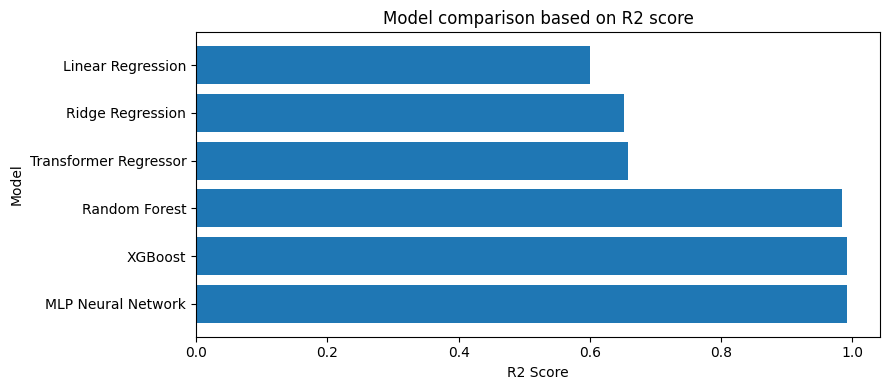

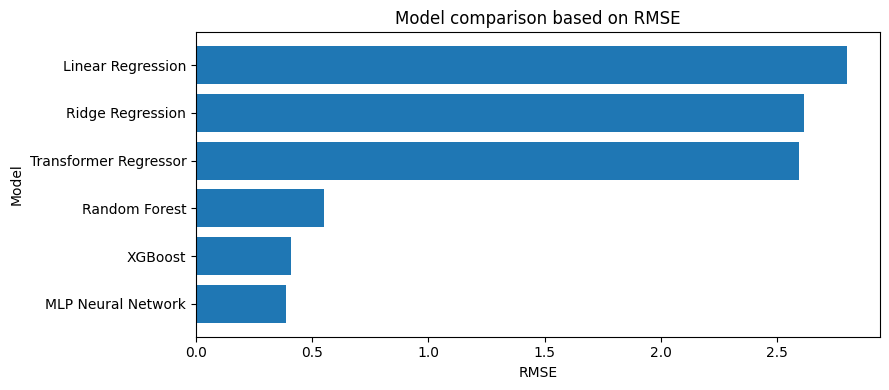

In [56]:
plt.figure(figsize=(9, 4))
plt.barh(
    results_df_rounded['Model'],
    results_df_rounded['R2 Score']
)
plt.title('Model comparison based on R2 score')
plt.xlabel('R2 Score')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4))
rmse_df = results_df_rounded.sort_values('RMSE')
plt.barh(
    rmse_df['Model'],
    rmse_df['RMSE']
)
plt.title('Model comparison based on RMSE')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## 18. Visualisation

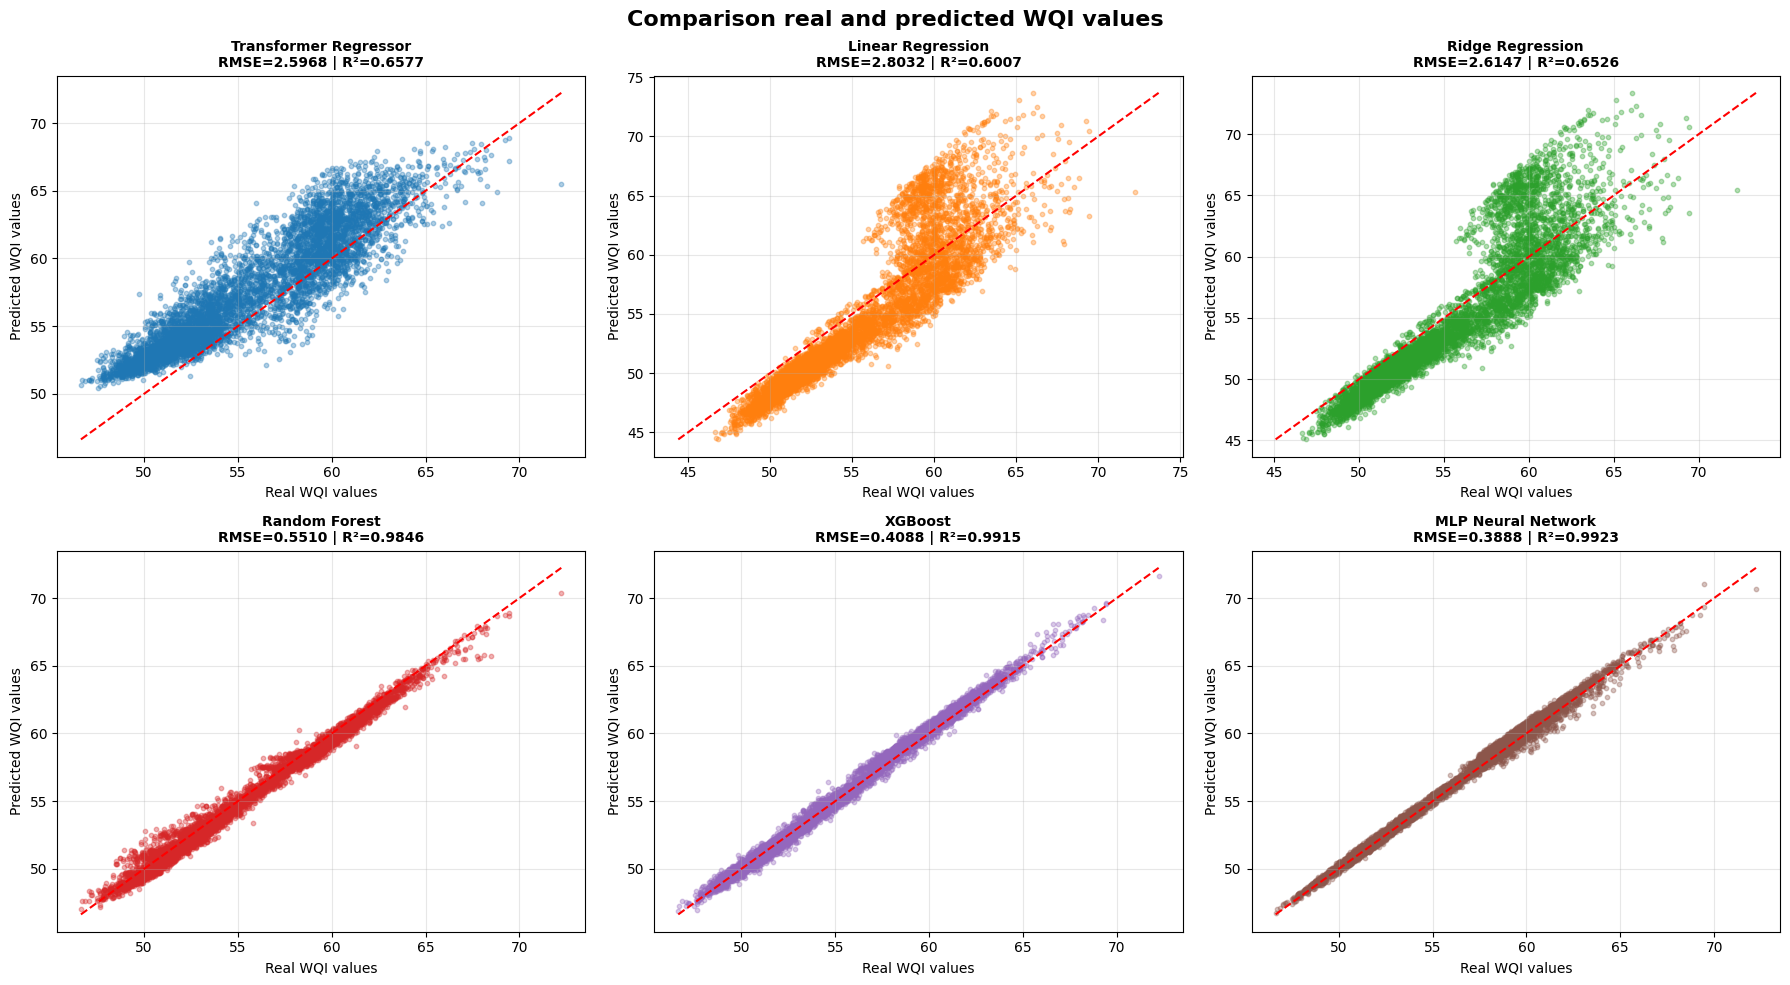

In [57]:
n_models = len(all_predictions)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

colors = [
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#d62728',
    '#9467bd',
    '#8c564b'
]

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, (name, y_pred) in enumerate(all_predictions.items()):
    ax = axes[i]

    if name == 'Transformer Regressor':
        y_true = np.asarray(yte_seq)
    else:
        y_true = np.asarray(y_test)

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[-min_len:]
    y_pred = y_pred[-min_len:]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    ax.scatter(
        y_true,
        y_pred,
        alpha=0.35,
        s=10,
        color=colors[i % len(colors)]
    )

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())

    ax.plot(
        [mn, mx],
        [mn, mx],
        'r--',
        linewidth=1.5
    )

    ax.set_title(
        f'{name}\nRMSE={rmse:.4f} | R²={r2:.4f}',
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel('Real WQI values')
    ax.set_ylabel('Predicted WQI values')
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Comparison real and predicted WQI values',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 19. Best model

,Timestamp,Real WQI,Predicted WQI,Error
0,2024-04-15 09:50:00,52.568641,52.574364,-0.005723
1,2024-04-15 10:00:00,52.902299,53.065593,-0.163294
2,2024-04-15 10:10:00,53.085692,53.267550,-0.181858
3,2024-04-15 10:20:00,55.906812,55.956121,-0.049309
4,2024-04-15 10:30:00,53.666192,53.535835,0.130356
5,2024-04-15 10:40:00,61.361248,61.788212,-0.426964
6,2024-04-15 10:50:00,52.126871,52.264833,-0.137962
7,2024-04-15 11:00:00,56.022886,56.133574,-0.110688
8,2024-04-15 11:10:00,52.918743,52.879444,0.039299
9,2024-04-15 11:20:00,54.590030,54.742948,-0.152918


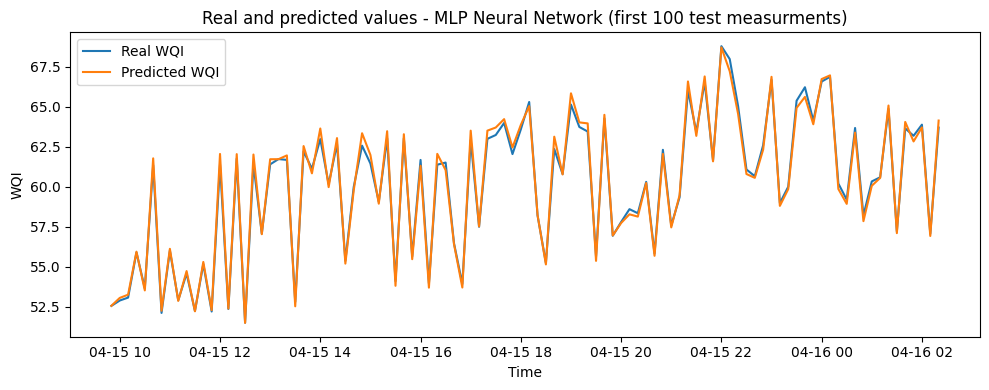

In [58]:
if best_model_name == 'Transformer Regressor':
    best_true = yte_seq
    best_pred = all_predictions[best_model_name]
    best_index = y_test.index[SEQ_LEN-1:]
else:
    best_true = y_test.values
    best_pred = all_predictions[best_model_name]
    best_index = y_test.index

comparison_df = pd.DataFrame({
    'Timestamp': best_index,
    'Real WQI': best_true,
    'Predicted WQI': best_pred,
    'Error': best_true - best_pred
})

display(comparison_df.head(20))

plt.figure(figsize=(10, 4))
plt.plot(
    comparison_df['Timestamp'].iloc[:100],
    comparison_df['Real WQI'].iloc[:100],
    label='Real WQI'
)

plt.plot(
    comparison_df['Timestamp'].iloc[:100],
    comparison_df['Predicted WQI'].iloc[:100],
    label='Predicted WQI'
)

plt.title(
    f'Real and predicted values - {best_model_name} '
    f'(first 100 test measurments)'
)

plt.xlabel('Time')
plt.ylabel('WQI')
plt.legend()
plt.tight_layout()
plt.show()

## 20. Feature importance

,Atribute,Importance
7,Turbidity,0.800663
2,Chlorophyll,0.120529
4,Dissolved Oxygen,0.070764
5,pH,0.003478
11,Day_of_Year,0.001282
6,Specific Conductance,0.001109
3,Temperature,0.000661
12,Hour,0.000367
8,Rainfall,0.000320
0,Average Water Speed,0.000275


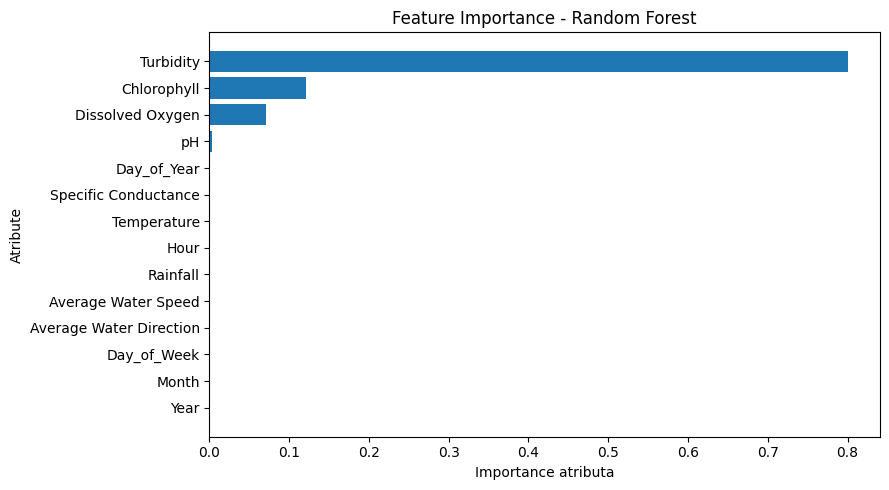

,Atribute,Importance
9,Year,0.455364
7,Turbidity,0.406668
2,Chlorophyll,0.066982
4,Dissolved Oxygen,0.041424
11,Day_of_Year,0.010450
5,pH,0.009496
6,Specific Conductance,0.005921
3,Temperature,0.001502
10,Month,0.001380
12,Hour,0.000649


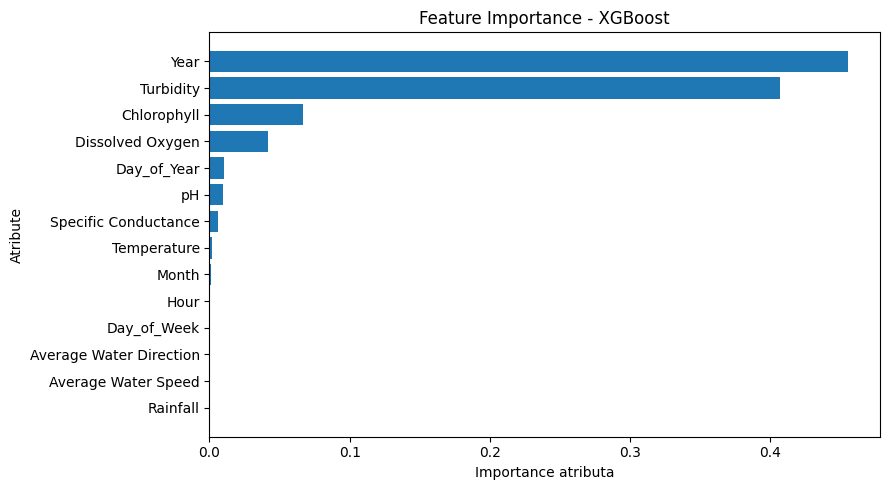

In [60]:
for model_name in ['Random Forest', 'XGBoost']:

    if model_name in best_models:
        model = best_models[model_name]

        if hasattr(model, 'feature_importances_'):

            importance_df = pd.DataFrame({
                'Atribute': X.columns,
                'Importance': model.feature_importances_
            }).sort_values('Importance', ascending=False)

            display(importance_df)

            plt.figure(figsize=(9, 5))
            plt.barh(
                importance_df['Atribute'],
                importance_df['Importance']
            )

            plt.title(f'Feature Importance - {model_name}')
            plt.xlabel('Importance atributa')
            plt.ylabel('Atribute')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()